# Look at the Stereo Images

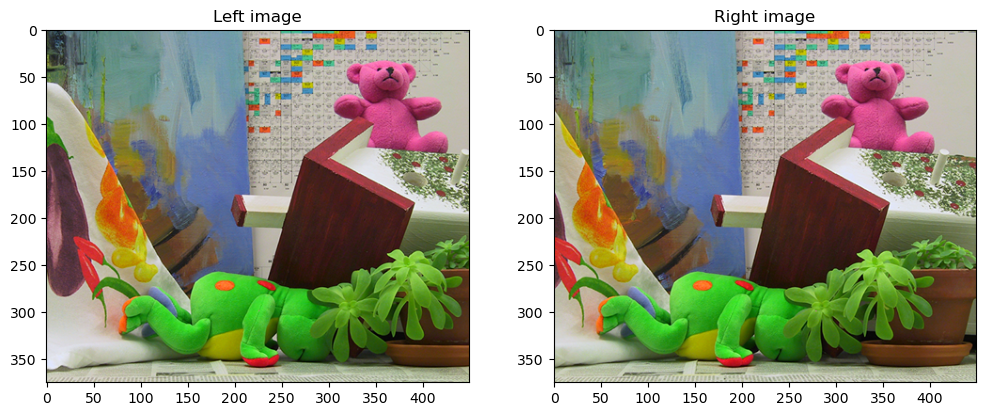

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_left  = cv2.imread('data/im2.ppm')
img_right = cv2.imread('data/im6.ppm')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(cv2.cvtColor(img_left,  cv2.COLOR_BGR2RGB))
ax1.set_title('Left image')
ax2.imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
ax2.set_title('Right image')
plt.show()


# Convert to Grayscale

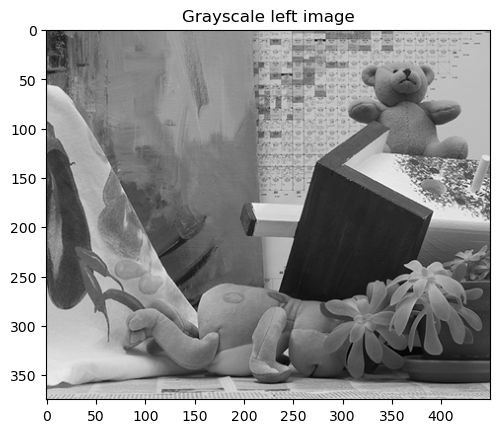

In [49]:
# Harris works on grayscale
gray_left  = cv2.cvtColor(img_left,  cv2.COLOR_BGR2GRAY).astype(np.float64)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.imshow(gray_left, cmap='gray')
plt.title('Grayscale left image')
plt.show()

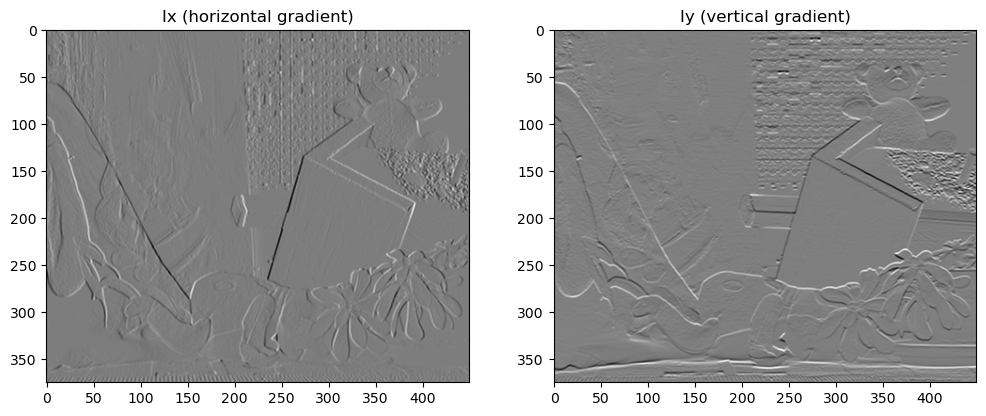

In [50]:
# First, let's write down our Sobel Corners!
Kx = np.array([
    [-1, 0, 1],   # subracts left side by right side
    [-2, 0, 2],   # weighted more in the center row
    [-1, 0, 1]], dtype=np.float64)

# take the transform for Y
Ky = Kx.T

def convolve2d(img, kernel):
    # obtain the shape of the kernel
    kh, kw = kernel.shape

    # for a 3 by 3 kernel we need 1 px pad
    pad_h, pad_w = kh //2 , kw//2 

    # this does padding for the squares outside of the image
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    # create new image
    output = np.zeros_like(img)

    # double for loop once structure is correct we can vectorize
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)
    return output

    
Ix = convolve2d(gray_left, Kx)
Iy = convolve2d(gray_left, Ky)

def print_images(Ix, Iy):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(Ix, cmap='gray')
    ax1.set_title('Ix (horizontal gradient)')
    ax2.imshow(Iy, cmap='gray')
    ax2.set_title('Iy (vertical gradient)')
    plt.show()

print_images(Ix, Iy)

Here we can see the corrsipoding horizontal and vertical gradients 

# Structure Tensor
- now it's time to build a structure tensor

In [51]:
# lets first compute the three components that we need!
Ixx = Ix ** 2 ## remeber each of these are the same size as the image
Iyy = Iy ** 2
Ixy = Ix * Iy

these three componenets will turn into the tensor
$$
M = \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}
$$

In [52]:
# we need to average these values over a small kernel this gives us
# the graidient distribution in a region around each pixel
def gaussian_kernel(size, sigma=1):
    k = size // 2
    
    # mgrid creates two 2D grids of x and y distances from the center
    # each value represents how far that position is from the kernel center
    x, y = np.mgrid[-k:k+1, -k:k+1]
    
    # Gaussian formula: pixels closer to center get exponentially more weight
    # sigma controls how quickly the weight drops off with distance
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # normalize so all weights sum to 1 (preserves image brightness)
    return kernel / kernel.sum()

gauss = gaussian_kernel(5, sigma=1.0)

# Smooth each structure tensor component
Sxx = convolve2d(Ixx, gauss)
Syy = convolve2d(Iyy, gauss)
Sxy = convolve2d(Ixy, gauss)

In [53]:
k = 0.05  # Harris sensitivity parameter, typically 0.04-0.06

# because computing the eigen values is compute heavy instead we can just use
# the determinate and trace to obtain the same result
det_M   = Sxx * Syy - Sxy ** 2       # det(M) = λ1·λ2
trace_M = Sxx + Syy                   # trace(M) = λ1+λ2

# subract the determinate by the result of the harris sensitive param and 
# the trace of the eigen values squared
R = det_M - k * (trace_M ** 2)

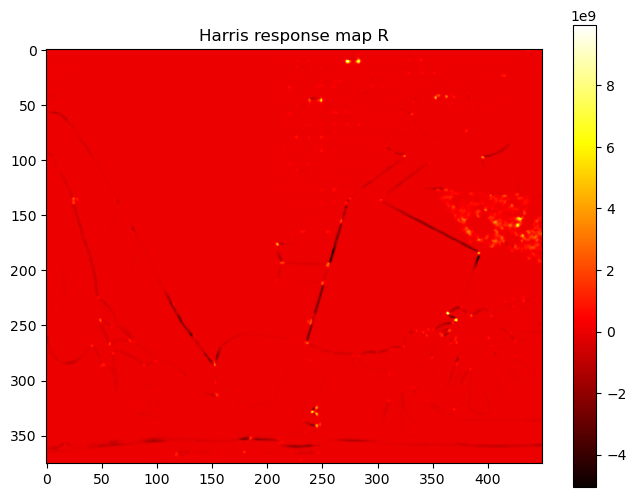

In [54]:
# Visualize the response map
plt.figure(figsize=(8, 6))
plt.imshow(R, cmap='hot')
plt.colorbar()
plt.title('Harris response map R')
plt.show()

In [55]:
def non_max_suppression(R, window_size=10, threshold=1e8):
    corners = []
    h, w = R.shape
    pad = window_size // 2
    
    # pad the response map so we can check borders
    R_padded = np.pad(R, pad, mode='constant', constant_values=0)
    
    for i in range(pad, h + pad):
        for j in range(pad, w + pad):
            # extract the local window around this pixel
            window = R_padded[i-pad:i+pad+1, j-pad:j+pad+1]
            
            # only keep it if:
            # 1. it's above the threshold (strong enough response)
            # 2. it's the maximum in its neighborhood
            if R_padded[i, j] == window.max() and R_padded[i, j] > threshold:
                corners.append((j - pad, i - pad))  # (x, y)
    
    return corners

corners_left = non_max_suppression(R, window_size=10, threshold=4e6)
print(f"Found {len(corners_left)} corners")

Found 491 corners


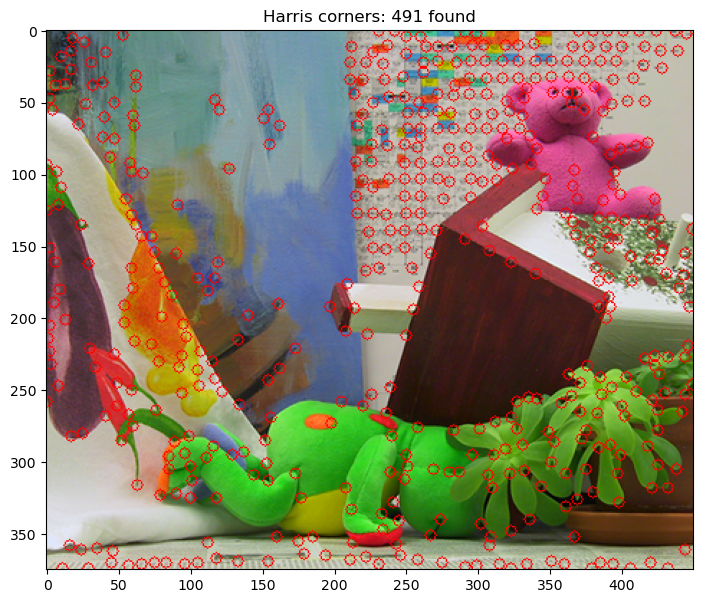

In [56]:
# draw corners on the original image
img_corners = cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB).copy()

for (x, y) in corners_left:
    cv2.circle(img_corners, (x, y), radius=4, color=(255, 0, 0), thickness=1)

plt.figure(figsize=(10, 7))
plt.imshow(img_corners)
plt.title(f'Harris corners: {len(corners_left)} found')
plt.show()

# Right Image

In [57]:
# compute gradients for right image
Ix_r = convolve2d(gray_right, Kx)
Iy_r = convolve2d(gray_right, Ky)

# structure tensor
Ixx_r = Ix_r ** 2
Iyy_r = Iy_r ** 2
Ixy_r = Ix_r * Iy_r

# smooth
Sxx_r = convolve2d(Ixx_r, gauss)
Syy_r = convolve2d(Iyy_r, gauss)
Sxy_r = convolve2d(Ixy_r, gauss)

# Harris response
det_r   = Sxx_r * Syy_r - Sxy_r ** 2
trace_r = Sxx_r + Syy_r
R_right = det_r - k * (trace_r ** 2)

corners_right = non_max_suppression(R_right, window_size=10, threshold=4e6)
print(f"Found {len(corners_right)} corners in right image")

Found 503 corners in right image


In [58]:
def extract_patches(img, corners, patch_size=15):
    """
    For each corner, extract a flattened patch of pixels around it.
    This becomes the descriptor we use for matching.
    """
    descriptors = []
    valid_corners = []
    pad = patch_size // 2
    
    # pad the image so corners near the border still get a full patch
    padded = np.pad(img, pad, mode='reflect')
    
    for (x, y) in corners:
        # extract the patch centered on this corner
        patch = padded[y:y+patch_size, x:x+patch_size]
        
        # normalize the patch (zero mean, unit variance)
        # this makes matching robust to brightness differences
        patch = patch - patch.mean()
        std = patch.std()
        if std > 0:
            patch = patch / std
        
        descriptors.append(patch.flatten())
        valid_corners.append((x, y))
    
    return np.array(descriptors), valid_corners

desc_left,  corners_left_valid  = extract_patches(gray_left,  corners_left)
desc_right, corners_right_valid = extract_patches(gray_right, corners_right)

print(f"Left  descriptors shape: {desc_left.shape}")
print(f"Right descriptors shape: {desc_right.shape}")

Left  descriptors shape: (491, 225)
Right descriptors shape: (503, 225)


In [59]:
def match_descriptors(desc1, desc2, corners1, corners2, ratio=0.75):
    """
    For each descriptor in image 1, find the two nearest neighbors in image 2.
    Apply Lowe's ratio test: only keep the match if the best match is 
    significantly better than the second best.
    """
    matches = []
    
    for i, d1 in enumerate(desc1):
        # compute SSD between d1 and every descriptor in image 2
        diff = desc2 - d1          # broadcast subtraction
        ssd  = np.sum(diff**2, axis=1)   # sum of squared differences
        
        # get the two smallest SSD values
        idx = np.argsort(ssd)
        best, second = idx[0], idx[1]
        
        # Lowe's ratio test:
        # if best match is much better than second best, it's a good match
        if ssd[best] < ratio * ssd[second]:
            matches.append((i, best))
    
    return matches

matches = match_descriptors(desc_left, desc_right, 
                             corners_left_valid, corners_right_valid)
print(f"Found {len(matches)} matches")

Found 321 matches


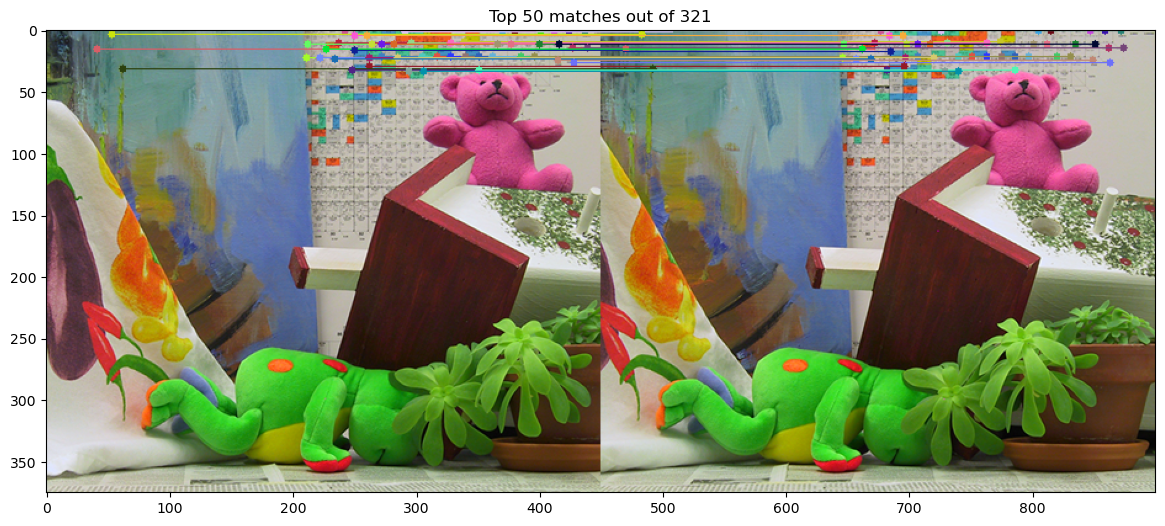

In [60]:
def draw_matches(img1, img2, corners1, corners2, matches, max_draw=50):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # place both images side by side
    canvas = np.zeros((max(h1,h2), w1+w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    canvas[:h2, w1:] = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # draw lines between matched corners
    for i, (idx1, idx2) in enumerate(matches[:max_draw]):
        x1, y1 = corners1[idx1]
        x2, y2 = corners2[idx2]
        x2_shifted = x2 + w1   # shift right image coords
        
        color = tuple(np.random.randint(0, 255, 3).tolist())
        cv2.line(canvas, (x1,y1), (x2_shifted, y2), color, 1)
        cv2.circle(canvas, (x1, y1), 3, color, -1)
        cv2.circle(canvas, (x2_shifted, y2), 3, color, -1)
    
    plt.figure(figsize=(16, 6))
    plt.imshow(canvas)
    plt.title(f'Top {min(max_draw, len(matches))} matches out of {len(matches)}')
    plt.show()

draw_matches(img_left, img_right, 
             corners_left_valid, corners_right_valid, matches)

# 🎯 Next Steps — Fundamental Matrix Pipeline

## ✅ Completed
- Harris corner detection (from scratch)
- Patch descriptors (15×15 normalized patches)
- Nearest neighbor matching with Lowe's ratio test

---

## 📍 Where we left off
321 matches found, most are correct (horizontal lines) but some outliers exist
(diagonal lines shooting to top of image). RANSAC will clean these up.

---

## Phase 3 — Fundamental Matrix

### Step 1 — Hartley Normalization
- Extract point arrays `pts1`, `pts2` from matches
- Translate points so centroid is at origin
- Scale so average distance to origin is √2
- Build 3×3 transformation matrix T for each image
- **Verify:** print mean and std of normalized points

### Step 2 — 8-Point Algorithm
- Build the 9-column design matrix A from normalized point pairs
- Take SVD of A → last row of Vᵀ is the F matrix (reshaped to 3×3)
- Enforce rank-2 constraint: SVD of F, zero out smallest singular value
- Denormalize: `F = T2ᵀ @ F_norm @ T1`
- **Verify:** check `rank(F) == 2` and `det(F) ≈ 0`

### Step 3 — RANSAC
- Randomly sample 8 point pairs
- Compute F using 8-point algorithm
- Count inliers using Sampson distance (threshold ~0.01)
- Repeat N times, keep F with most inliers
- Refit F using all inliers of best model
- **Verify:** visualize inlier matches only (should be all horizontal)

### Step 4 — Epipolar Line Visualization
- For points in left image compute epipolar line in right: `l' = Fx`
- Draw lines on right image and check they pass through matched point
- **Verify:** matched point should lie exactly on its epipolar line

---

## Phase 4 — Rectification
- Compute epipoles (null space of F and Fᵀ)
- Build homographies H1, H2 to map epipoles to infinity
- Warp both images using bilinear interpolation (from scratch)
- **Verify:** epipolar lines should be perfectly horizontal after rectification

---

## Phase 5 — Disparity Map
- Implement SAD block matching on rectified images
- For each pixel in left image, slide window along same row in right
- Pick disparity d with minimum SAD score
- Colormap the disparity map and compare against `disp2.pgm`

---

## Phase 6 — Depth & Point Cloud
- Convert disparity to depth: `Z = (f × B) / d`
- Back-project pixels to 3D (X, Y, Z)
- Visualize as a 3D scatter plot with matplotlib

---

## 📦 Reminder — move working functions to `utils.py`
- `convolve2d()`
- `gaussian_kernel()`
- `non_max_suppression()`
- `extract_patches()`
- `match_descriptors()`